# IAD Pipeline
Anomaly detection pipeline using FiftyOne, Weights & Biases, and the IAD framework.

## 1. Environment Setup
Configure database URI and API keys.

In [1]:
import os

# Set BEFORE any fiftyone imports
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost"
os.environ["WANDB_API_KEY"] = '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'

# Now safe to import
import wandb
import logging
from pathlib import Path
from IAD import IAD

wandb.login()

/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
wandb: Currently logged in as: daniel-pommer (daniel-pommer-technische-hochschule-n-rnberg-georg-simon-ohm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Configuration
Set your run parameters here before executing the pipeline.

In [2]:
tiling      = True
modelName   = "Padim"
datasetName = "MVTecADShort"
category    = "cable"
train       = True
evaluate    = True
datasetDir = Path("../datasets/")
configDir=Path("../configs/")
outputPath=Path("../results/")

## 3. Initialise Logger & IAD

In [3]:
logger = logging.getLogger("logger")
logger.debug("This should go to mongodb.log")

iad = IAD(configDir=configDir, datasetDir=datasetDir,outputPath=outputPath)

## 4. Load Dataset & Generate Model

In [4]:
iad.generateModel(f"{modelName}.yaml")
datasetPath = datasetDir/datasetName
iad.loadDatasetFromDisk(datasetPath, datasetName, overwrite=False, merge=False)
iad.selectCategory(category)
iad.adjustOutputPath()
iad.copyFilesToOutputPath()

if iad.dataset is None:
    raise RuntimeError("Dataset failed to load — check your dataset path and name.")
if tiling:
    iad.setupTiling(configDir / "TiledEnsemble.yaml")
iad.adjustOutputPath()

INFO: Model Padim loaded: {'model': {'class_path': 'Padim', 'init_args': {'backbone': 'resnet18', 'layers': ['layer1', 'layer2', 'layer3'], 'pre_trained': True, 'n_features': 100, 'pre_processor': PreProcessor(), 'post_processor': AOIPostProcessor(
  (_image_threshold_metric): F1AdaptiveThreshold()
  (_pixel_threshold_metric): F1AdaptiveThreshold()
  (_image_min_max_metric): MinMax()
  (_pixel_min_max_metric): MinMax()
), 'visualizer': False, 'evaluator': Evaluator(
  (val_metrics): ModuleList(
    (0): AUROC()
  )
  (test_metrics): ModuleList(
    (0): AUROC()
    (1): F1Score()
    (2): AUPR()
  )
)}}}
INFO: Initializing Padim model.


/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Model Padim(
  (pre_processor): PreProcessor()
  (post_processor): AOIPostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList(
      (0): AUROC()
    )
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUPR()
    )
  )
  (model): PadimModel(
    (feature_extractor): TimmFeatureExtractor(
      (feature_extractor): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 

PosixPath('../results/MVTecADShort/cable/Padim/tiled')

## 4.1 Inspect Dataset


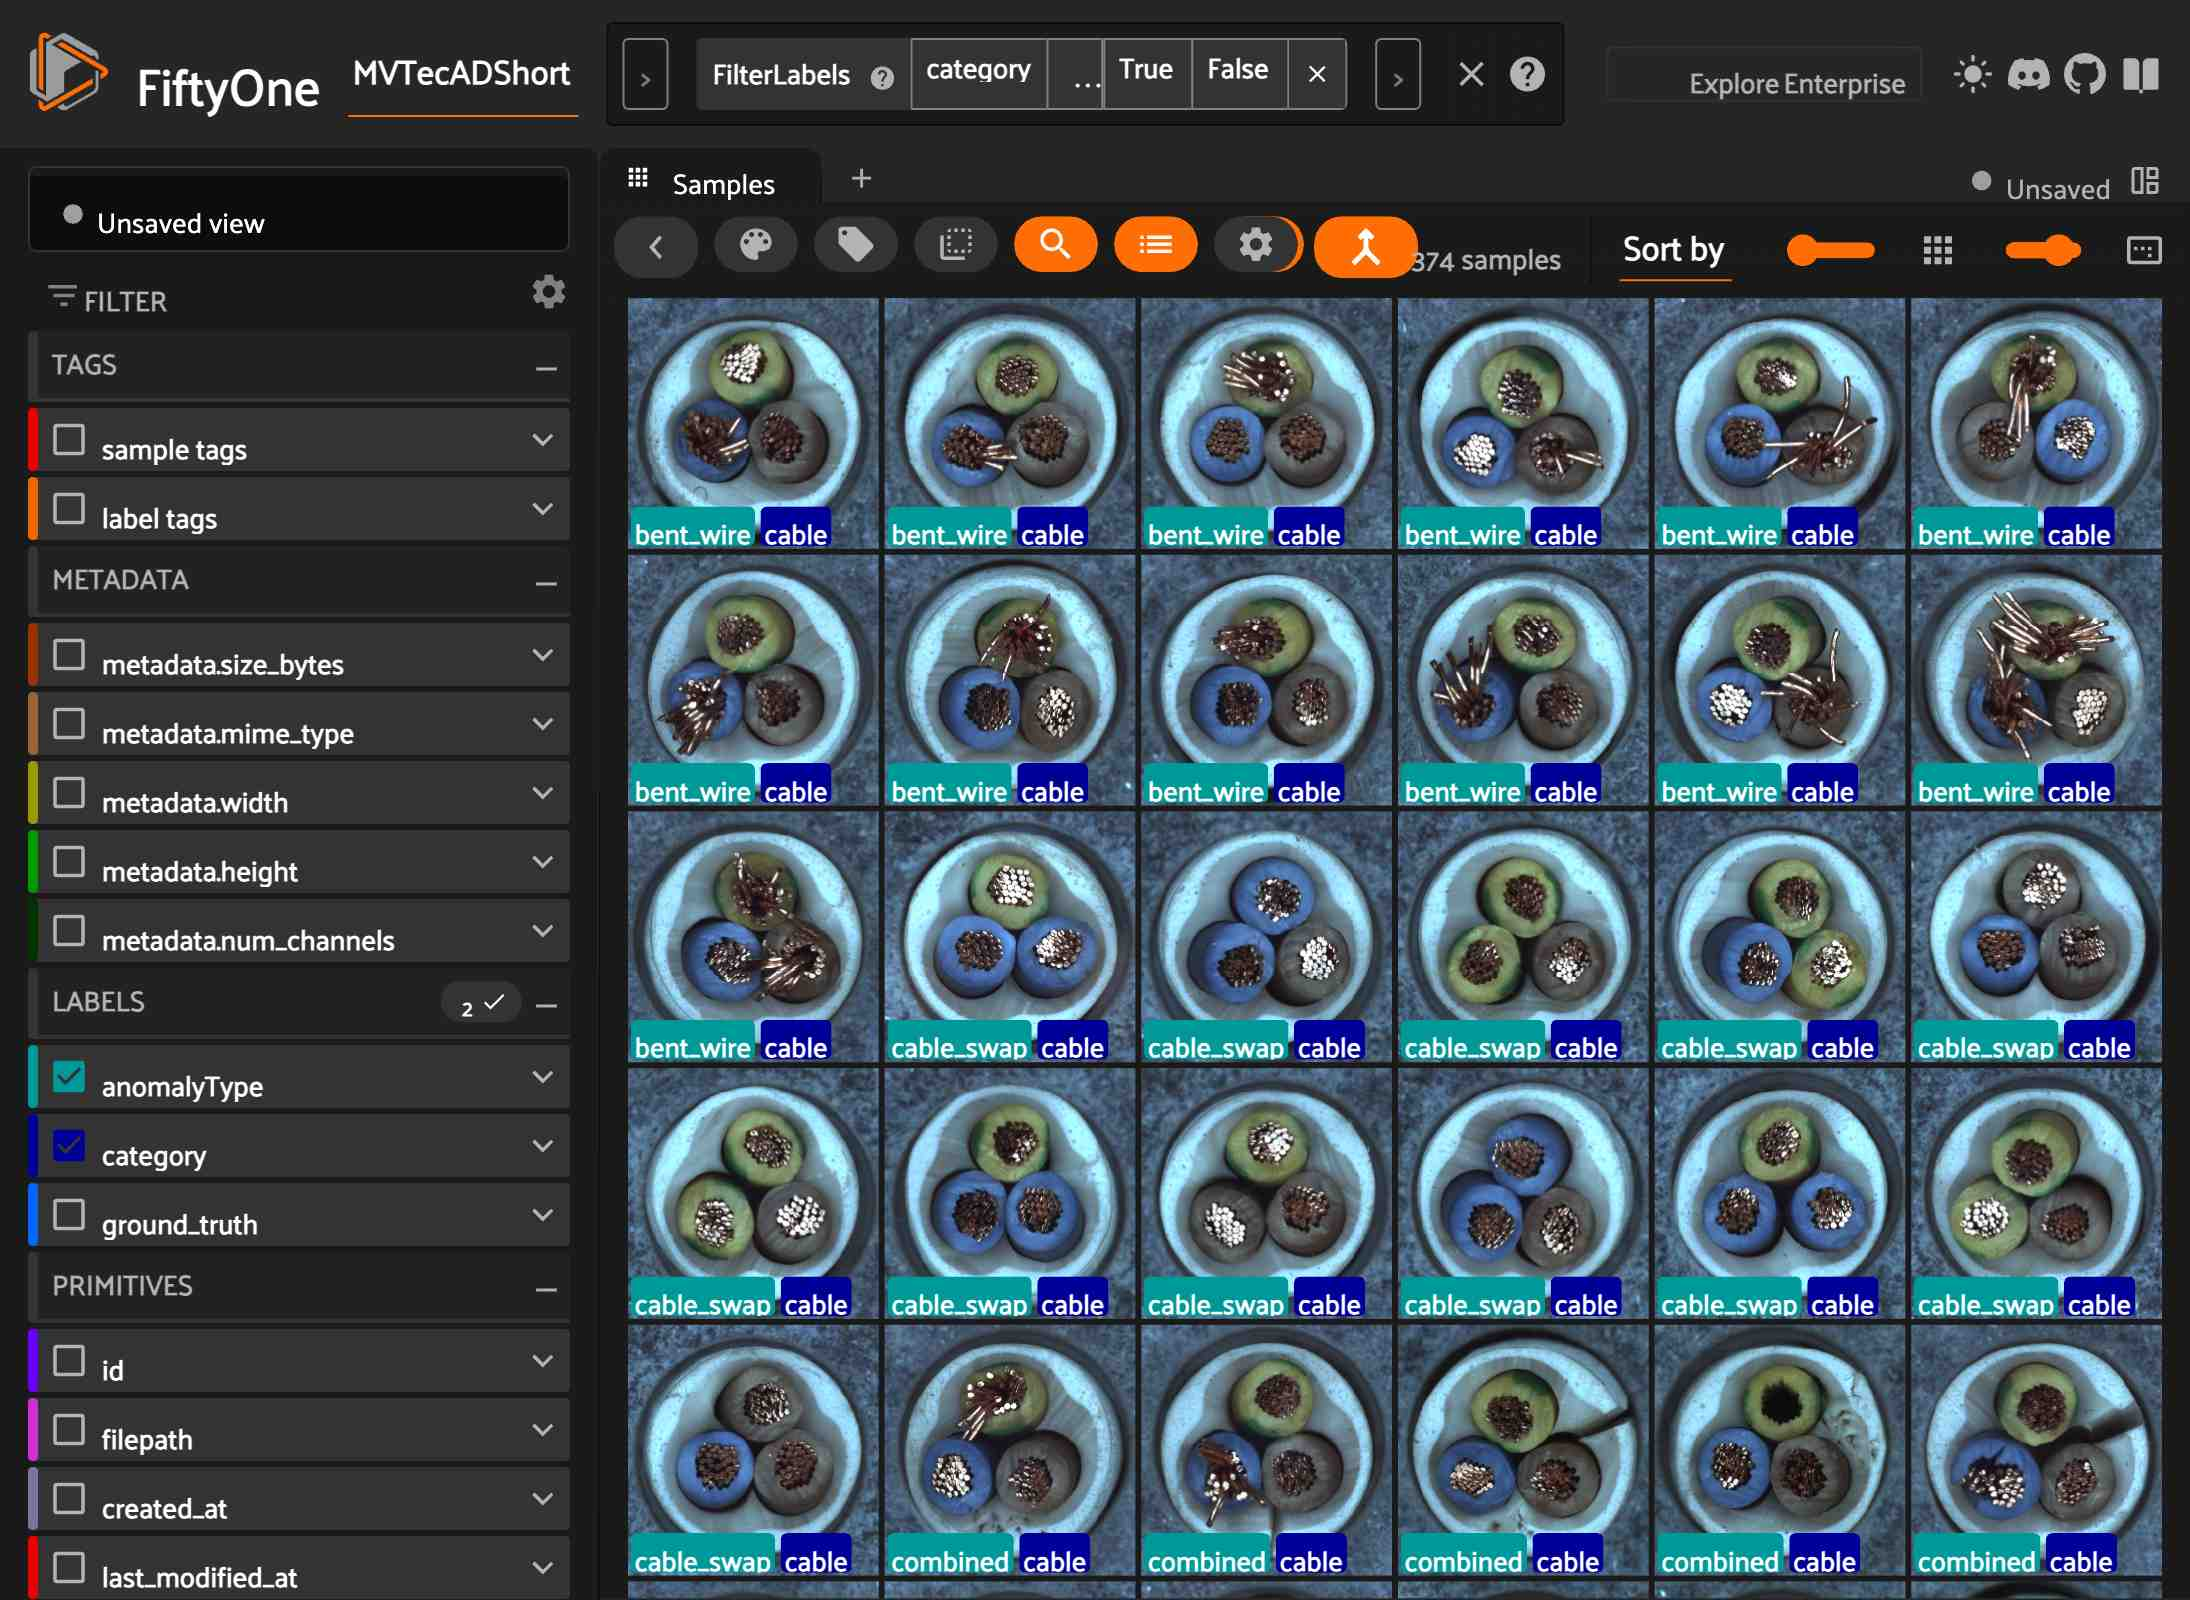

INFO: Session addess and port: localhost:5151


In [5]:
iad.launchSession()

## 5. Training

In [ ]:

if train:
    iad.train(configDir / Path(f"{modelName}_Training.yaml"), tiling=tiling)

## 6. Evaluation & Prediction

In [ ]:
if evaluate:
    if iad.ckptPath is not None:
        if not tiling:
            iad.loadCheckpoint(iad.ckptPath, f"{modelName}")
        iad.eval(configDir / "Eval.yaml", tiling=tiling)
        iad.launchSession()
    else:
        print("No checkpoint found — skipping evaluation.")
    

INFO: Running tiled ensemble test pipeline.
INFO: No ckptPath given in arguments to <class 'tiling.tiled_ensemble.EvalTiledEnsemble'>. Going over rootDir
INFO: Running job Predict


Predict: 0it [00:00, ?it/s]

INFO: Tiled ensemble predicting started using test data.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Loading the model.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)


/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Start of predicting for tile at position (0, 0),


...


Metrics: 0it [00:00, ?it/s]

INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Loading the model.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Starting metrics calculation.


Calculating metrics: 100%|██████████| 5/5 [00:00<00:00, 1425.37it/s]
Metrics: 1it [00:00,  1.09it/s]

image_AUROC: 0.8488
image_F1Score: 0.8409
image_AUPR: 0.8996
INFO: Saving metrics to csv.
INFO: Job Metrics completed successfully.


INFO: Session addess and port: localhost:5151


## 7. Evaluate on single unknown Image

In [ ]:
ckptPath = iad.ckptPath.parent.resolve()
print(ckptPath)

In [ ]:

# ckptPath = iad.ckptPath.parent.resolve()
# print(ckptPath)
iad.loadDatasetFromDisk(datasetPath=datasetDir / "MVTecADShortPred", datasetName="cablePred5", split=("pred",), overwrite=True)
# iad.selectCategory("cable")

if iad.ckptPath is not None:
    if not tiling:
        iad.loadCheckpoint(iad.ckptPath, f"{modelName}")
    iad.predict(config=configDir / "Predict.yaml", tiling=tiling, ckptPath=ckptPath)
    iad.launchSession()